# Programa de Capacitação de Processamento Digital de Sinais

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Desenvolvido por:
-   Elmer Pimentel Farias


# Filtros Adaptativos e Equalização de Canais

Filtros adaptativos são sistemas capazes de ajustar seus coeficientes automaticamente para minimizar um erro, adaptando-se a ambientes desconhecidos ou variantes no tempo. Diferente dos filtros fixos, eles operam em malha fechada, utilizando o erro entre a saída e um sinal desejado para atualizar seus pesos.



## Principais Algoritmos

* **LMS (Least Mean Squares):** O mais utilizado devido à sua simplicidade e baixo custo computacional. Baseia-se no gradiente estocástico para minimizar o erro quadrático médio.
    * **Equação de atualização:** $$\mathbf{w}(n+1) = \mathbf{w}(n) + \mu e(n) \mathbf{x}(n)$$
* **CMA (Constant Modulus Algorithm):** Essencial para **equalização cega** (sem sinal de referência), buscando restaurar o módulo constante de sinais modulados.
* **Outros (RLS, NLMS):** O **RLS** oferece convergência rápida com maior custo computacional, enquanto o **NLMS** normaliza o passo de adaptação para maior estabilidade.



## Livro-Texto Base

> **Adaptive Filtering: Algorithms and Practical Implementation (5ed)**
> *Paulo S. R. Diniz* 

Caps. 1, 2, 3 e 13

## Objetivos da Capacitação 

1.  **Implementação:** Codificar o algoritmo **LMS**.
2.  **Aplicação:** Realizar a **equalização de um canal passa-baixas**, visando mitigar a Interferência Intersimbólica (ISI).
3.  **Avaliação de Desempenho:**
    * Utilizar o **MSE (Mean Squared Error)** como métrica de convergência.
    * Analisar o impacto do **passo de adaptação ($\mu$)** (velocidade vs. erro residual).
    * Testar a robustez do sistema sob diferentes condições de **SNR**.


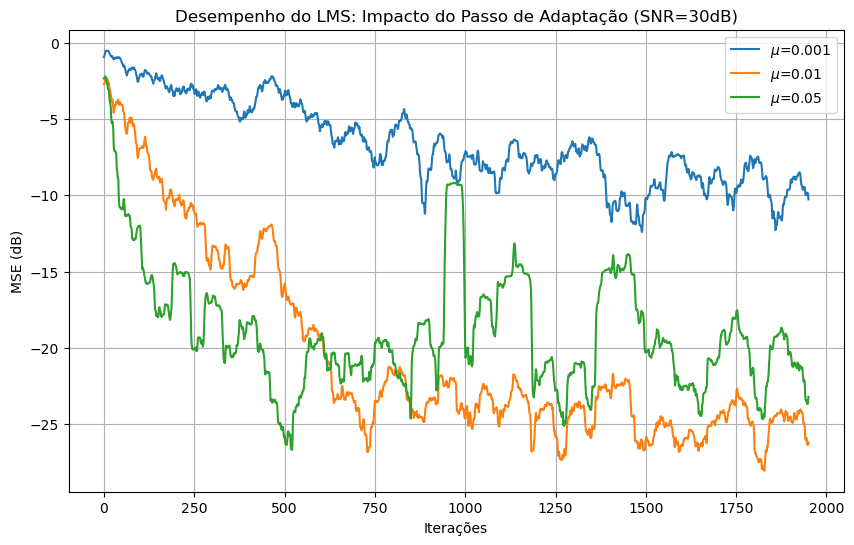

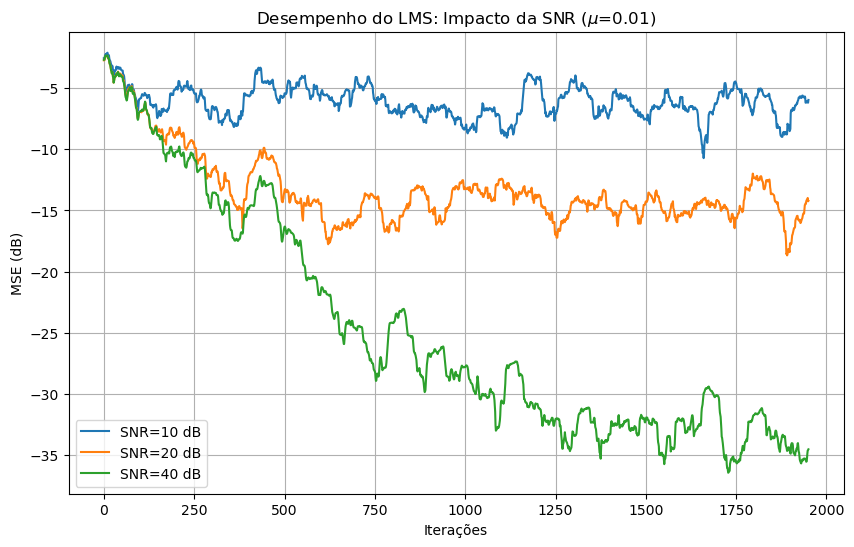

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def lms_equalizer(signal_received, signal_transmitted, num_taps, mu, delay):
    """
    Implementação do algoritmo LMS para equalização de canal.
    
    Args:
        signal_received: Sinal distorcido pelo canal + ruído (entrada do filtro)
        signal_transmitted: Sinal original (para referência)
        num_taps: Ordem do filtro (número de coeficientes)
        mu: Passo de adaptação (step size)
        delay: Atraso para sincronização do sinal desejado
        
    Returns:
        mse_curve: Curva de aprendizado (MSE estimado)
        w: Coeficientes finais do filtro
        y: Sinal equalizado
    """
    n_samples = len(signal_received)
    w = np.zeros(num_taps)  # Inicialização dos pesos com zero [cite: 2693]
    y = np.zeros(n_samples)
    e = np.zeros(n_samples)
    mse_curve = []
    
    # Buffer para linha de atraso (input vector)
    x = np.zeros(num_taps)
    
    for k in range(n_samples):
        # Atualiza o vetor de entrada (linha de atraso)
        # Desloca e insere a amostra atual
        x[1:] = x[:-1]
        x[0] = signal_received[k]
        
        # Filtragem (Produto interno)
        y[k] = np.dot(w, x)
        
        # Sinal desejado (Sinal transmitido atrasado)
        # Se k < delay, d(k) é assumido 0 ou ignorado
        if k >= delay:
            d = signal_transmitted[k - delay]
        else:
            d = 0
            
        # Cálculo do erro
        e[k] = d - y[k]
        
        # Atualização dos coeficientes (LMS Standard)
        # w(k+1) = w(k) + 2 * mu * e(k) * x(k)
        w = w + 2 * mu * e[k] * x
        
        # Estimativa instantânea do MSE (para plotagem)
        mse_curve.append(e[k]**2)
        
    return np.array(mse_curve), w, y

# --- Configuração da Simulação ---
np.random.seed(42)
N_SAMPLES = 2000
FILTER_ORDER = 11  # Número de Taps
DELAY = int(FILTER_ORDER / 2) # Atraso de grupo aproximado

# 1. Gerar sinal transmitido (Símbolos aleatórios +/- 1)
s = 2 * np.random.randint(0, 2, N_SAMPLES) - 1

# 2. Definir Canal Passa-Baixas (Causa ISI)
# Canal H(z) = 0.3 + 0.9z^-1 + 0.3z^-2 (Passa-baixas simples)
channel = np.array([0.3, 0.9, 0.3])
x_clean = np.convolve(s, channel, mode='same')

# --- Análise 1: Variação do Passo de Adaptação (mu) ---
# Mantendo SNR fixo em 30dB
SNR_dB = 30
signal_power = np.mean(x_clean**2)
noise_power = signal_power / (10**(SNR_dB/10))
noise = np.sqrt(noise_power) * np.random.randn(N_SAMPLES)
x_noisy = x_clean + noise

# Testando diferentes mus
mus = [0.001, 0.01, 0.05]
results_mu = {}

plt.figure(figsize=(10, 6))
for mu in mus:
    mse, w_final, y_est = lms_equalizer(x_noisy, s, FILTER_ORDER, mu, DELAY)
    
    # Suavização da curva de MSE para visualização (média móvel)
    window = 50
    mse_smooth = np.convolve(mse, np.ones(window)/window, mode='valid')
    
    results_mu[mu] = mse_smooth
    plt.plot(10 * np.log10(mse_smooth), label=f'$\mu$={mu}')

plt.title(f'Desempenho do LMS: Impacto do Passo de Adaptação (SNR={SNR_dB}dB)')
plt.xlabel('Iterações')
plt.ylabel('MSE (dB)')
plt.legend()
plt.grid(True)
plt.show()

# --- Análise 2: Variação da SNR ---
# Mantendo mu fixo em 0.01
mu_fixed = 0.01
snrs = [10, 20, 40] # dB

plt.figure(figsize=(10, 6))
for snr in snrs:
    # Gerar ruído específico para cada SNR
    noise_p = signal_power / (10**(snr/10))
    n = np.sqrt(noise_p) * np.random.randn(N_SAMPLES)
    x_in = x_clean + n
    
    mse, _, _ = lms_equalizer(x_in, s, FILTER_ORDER, mu_fixed, DELAY)
    
    # Suavização
    window = 50
    mse_smooth = np.convolve(mse, np.ones(window)/window, mode='valid')
    
    plt.plot(10 * np.log10(mse_smooth), label=f'SNR={snr} dB')

plt.title(f'Desempenho do LMS: Impacto da SNR ($\mu$={mu_fixed})')
plt.xlabel('Iterações')
plt.ylabel('MSE (dB)')
plt.legend()
plt.grid(True)
plt.show()